<a href="https://colab.research.google.com/github/Gokul-k11/data-science/blob/E-Commerce-Analysis/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce Analysis


In [ ]:
import pandas as pd
df=pd.read_csv("/content/customer_purchase_data.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,40439,2020-04-22 20:29:36,Books,243,3,729,Debit Card,44,0.0,James Thomas,44,Female,1
1,40439,2021-10-09 12:25:52,Toys,214,1,214,Debit Card,44,0.0,James Thomas,44,Female,0
2,40576,2021-10-05 05:12:57,Home,63,4,252,PayPal,26,0.0,Abigail Wilson,26,Other,0
3,40576,2023-05-12 17:01:48,Sports,393,3,1179,Credit Card,26,0.0,Abigail Wilson,26,Other,0
4,40582,2021-08-24 10:33:16,Home,232,1,232,PayPal,54,0.0,Daniel Rivera,54,Other,0


In [ ]:
top_category = df.groupby('Product Category')['Quantity'].sum().reset_index()
top_category = top_category.sort_values(by='Quantity', ascending=False)
best_seller = top_category.iloc[0]
print(best_seller)

Product Category    Home
Quantity              36
Name: 4, dtype: object


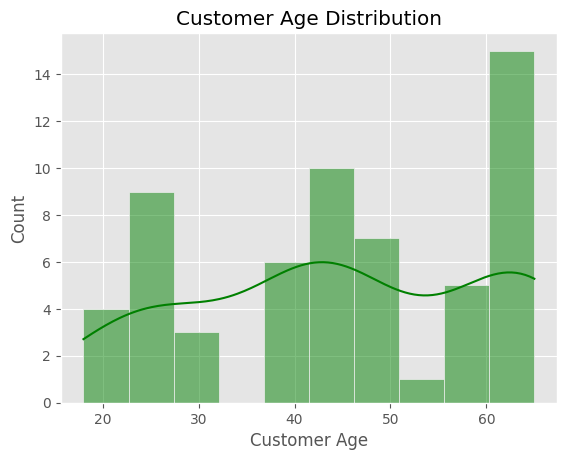

In [ ]:
sns.histplot(df['Customer Age'], kde=True, bins=10, color='g')
plt.title('Customer Age Distribution')
plt.xlabel('Customer Age')
plt.ylabel('Count')
plt.show()

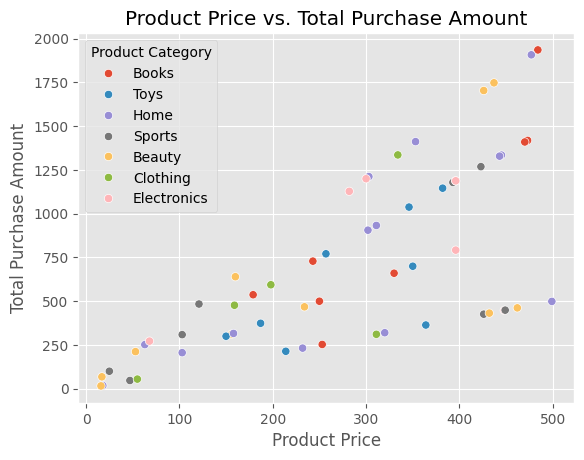

In [ ]:
sns.scatterplot(data=df, x='Product Price', y='Total Purchase Amount', hue='Product Category')
plt.title('Product Price vs. Total Purchase Amount')
plt.xlabel('Product Price')
plt.ylabel('Total Purchase Amount')
plt.show()

In [ ]:
payment_summary = df.groupby('Payment Method').agg(
    Transaction_Count=('Quantity', 'count'),
    Total_Revenue=('Total Purchase Amount', 'sum')
).reset_index()
print("Payment Method Comparison:")
print(payment_summary)

Payment Method Comparison:
  Payment Method  Transaction_Count  Total_Revenue
0           Cash                  8           6257
1    Credit Card                 23          18702
2     Debit Card                 12           8035
3         PayPal                 17           9549


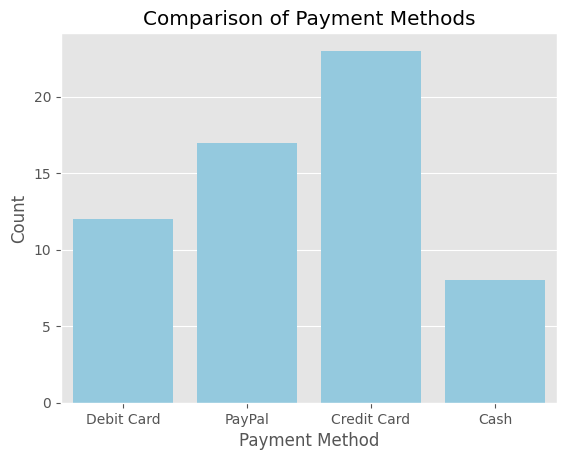

In [ ]:
sns.countplot(data=df, x='Payment Method',color="skyblue")
plt.title('Comparison of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                       Customer ID  Product Price  Quantity  \
Customer ID               1.000000       0.078082 -0.106875   
Product Price             0.078082       1.000000 -0.027365   
Quantity                 -0.106875      -0.027365  1.000000   
Total Purchase Amount    -0.007221       0.714893  0.577169   
Customer Age             -0.007196       0.078469  0.137145   
Returns                   0.123429      -0.082732  0.225516   
Age                      -0.007196       0.078469  0.137145   
Churn                     0.119044       0.040158 -0.100905   

                       Total Purchase Amount  Customer Age   Returns  \
Customer ID                        -0.007221     -0.007196  0.123429   
Product Price                       0.714893      0.078469 -0.082732   
Quantity                            0.577169      0.137145  0.225516   
Total Purchase Amount               1.000000      0.139482  0.125419   
Customer Age                        0.139482      1.

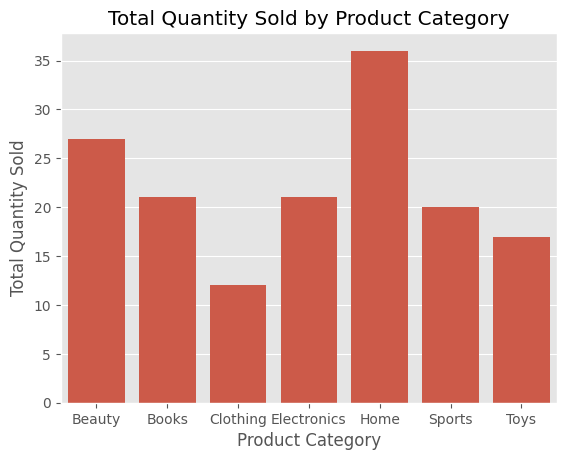

In [ ]:
sales = df.groupby('Product Category')['Quantity'].sum().reset_index()
sns.barplot(data=sales, x='Product Category', y='Quantity')
plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.show()

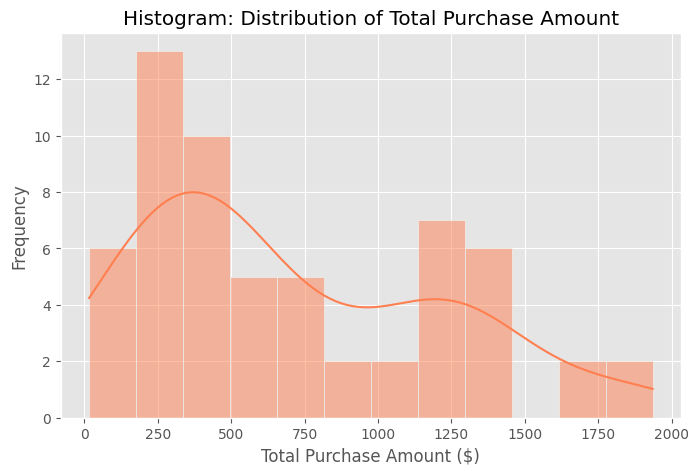

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Total Purchase Amount'], bins=12, kde=True, color='coral')
plt.title('Histogram: Distribution of Total Purchase Amount')
plt.xlabel('Total Purchase Amount ($)')
plt.ylabel('Frequency')
plt.show()

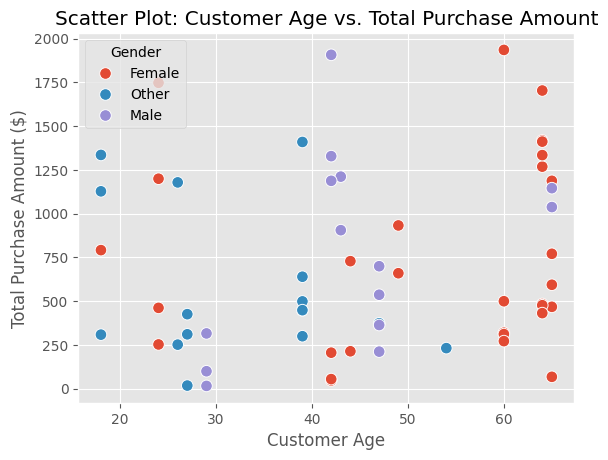

In [ ]:
sns.scatterplot(data=df, x='Customer Age', y='Total Purchase Amount', hue='Gender', s=70)
plt.title('Scatter Plot: Customer Age vs. Total Purchase Amount')
plt.xlabel('Customer Age')
plt.ylabel('Total Purchase Amount ($)')
plt.show()

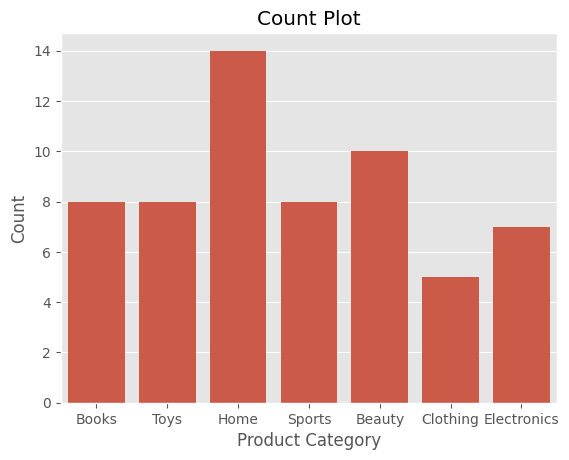

In [ ]:
sns.countplot(data=df, x='Product Category')
plt.title('Count Plot')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.show()

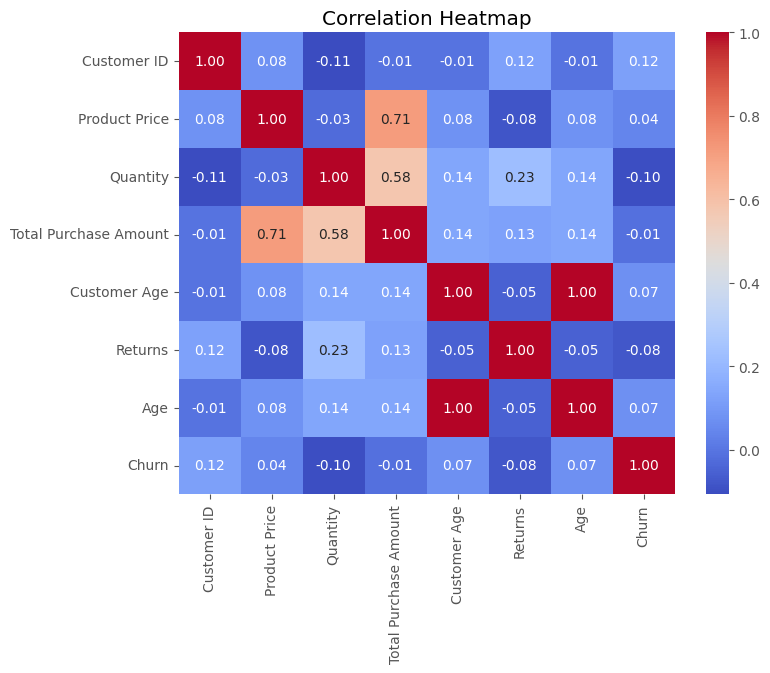

In [ ]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()